# INEGI:

In [12]:
import requests
import pandas as pd

url = "https://www.inegi.org.mx/app/tabulados/serviciocuadros/wsDataService.svc/listaindicadorbiinegi/910492/false/0700/es/json/2000/2026//0//0/3"
response = requests.get(url)


In [16]:
response.json()[0]['Data'][0]['Serie']['Obs'][1]['CurrentValue']

'49.037419255061'

In [9]:

data = response.json()[0]['Data']
metadata = data[0]['MetaData']
obs = data[0]['Serie']['Obs']
df = pd.DataFrame(obs)
df['Unit'] = metadata['Unit']
df['Indicador'] = metadata['Indicador']
df['Name'] = metadata['Name']
df['Freq'] = metadata['Freq']

df

,CurrentValue,TimePeriod,ValueNoNumeric,ValueStatus,Unit,Indicador,Name,Freq
0,48.719766378275,2003/12,,Definitiva,Índice base julio 2019 = 100,910492,INPP con Petróleo y con Servicios,Mensual
1,49.037419255061,2004/01,,Definitiva,Índice base julio 2019 = 100,910492,INPP con Petróleo y con Servicios,Mensual
2,49.622543649264,2004/02,,Definitiva,Índice base julio 2019 = 100,910492,INPP con Petróleo y con Servicios,Mensual
3,50.193052113554,2004/03,,Definitiva,Índice base julio 2019 = 100,910492,INPP con Petróleo y con Servicios,Mensual
4,50.699737683888,2004/04,,Definitiva,Índice base julio 2019 = 100,910492,INPP con Petróleo y con Servicios,Mensual
...,...,...,...,...,...,...,...,...
263,132.481923595456,2025/11,,Definitiva,Índice base julio 2019 = 100,910492,INPP con Petróleo y con Servicios,Mensual
264,133.128372825809,2025/12,,Definitiva,Índice base julio 2019 = 100,910492,INPP con Petróleo y con Servicios,Mensual
265,133.294768467889,2026/01,,Definitiva,Índice base julio 2019 = 100,910492,INPP con Petróleo y con Servicios,Mensual
266,133.547711990105,2026/02,,Definitiva,Índice base julio 2019 = 100,910492,INPP con Petróleo y con Servicios,Mensual


<Axes: >

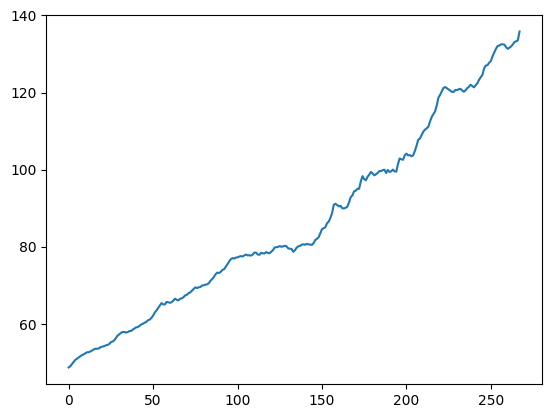

In [10]:
df['CurrentValue'].astype(float).plot()

# Serie A:

In [11]:
import requests
from bs4 import BeautifulSoup
import pandas as pd


def get_table(url):
    response = requests.get(url)

    # Parse the HTML content
    soup = BeautifulSoup(response.text, 'html.parser')

    tables = soup.find_all('table', {'cellpadding': '3', 'cellspacing': '1', 'class': 'standard_tabelle'})
    table = tables[0]

    rows = table.find_all('tr')
    # Iterate over each row
    df_all = pd.DataFrame()
    for row in rows:
        df = pd.DataFrame({'date': [row.find_all('td')[0].text.strip()],
                           'time': [row.find_all('td')[1].text.strip()],
                           'team1': [row.find_all('td')[2].text.strip()],
                           'team2': [row.find_all('td')[4].text.strip()],
                           'score': [row.find_all('td')[5].text.strip()]})
        df_all = pd.concat([df_all, df])
        
    return df_all

df_all = pd.DataFrame()

n=38
for i in range(1, n+1):
    print(f"Scraping page {i} out of {n}.")
    url = f"https://www.worldfootball.net/schedule/ita-serie-a-2023-2024-spieltag/{i}/"
    df_all = pd.concat([df_all, get_table(url)])


df_all

Scraping page 1 out of 38.


IndexError: list index out of range

In [ ]:
url = f"https://www.worldfootball.net/schedule/ita-serie-a-2023-2024-spieltag/1/"
response = requests.get(url)

response


# DANE:

In [ ]:
url = f"https://www.dane.gov.co/index.php/estadisticas-por-tema/cuentas-nacionales/cuentas-nacionales-trimestrales/historicos-producto-interno-bruto-pib"
response = requests.get(url)

soup = BeautifulSoup(response.text, 'html.parser')
soup


tables = soup.find_all('table', {'summary': 'Periodo de referencia 2023', 'class': 'table-bordered basic-table'})
table = tables[0]
table

rows = table.find_all('tr')
rows

links = soup.find_all('a', {'class': 'descarga'})
for i in range(8):
    print(links[i]['href'])